In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from pathlib import Path

In [8]:
df = pd.read_csv(r"C:\dev\study\miniproject\SKN27-2nd-1TEAM\00_data\Telco_customer_churn - Telco_Churn.csv")
df.columns = df.columns.str.replace(' ', '')
df.columns = df.columns.str.strip()
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'ZipCode', 'LatLong',
       'Latitude', 'Longitude', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'TenureMonths', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'ChurnLabel', 'ChurnValue', 'ChurnScore', 'CLTV', 'ChurnReason'],
      dtype='object')


In [9]:
# 'Yes'는 1로, 'No'는 0으로 변환하여 새로운 컬럼 생성
df['Churn_n'] = df['ChurnValue'].apply(lambda x: 1 if x == 'Yes' else 0)

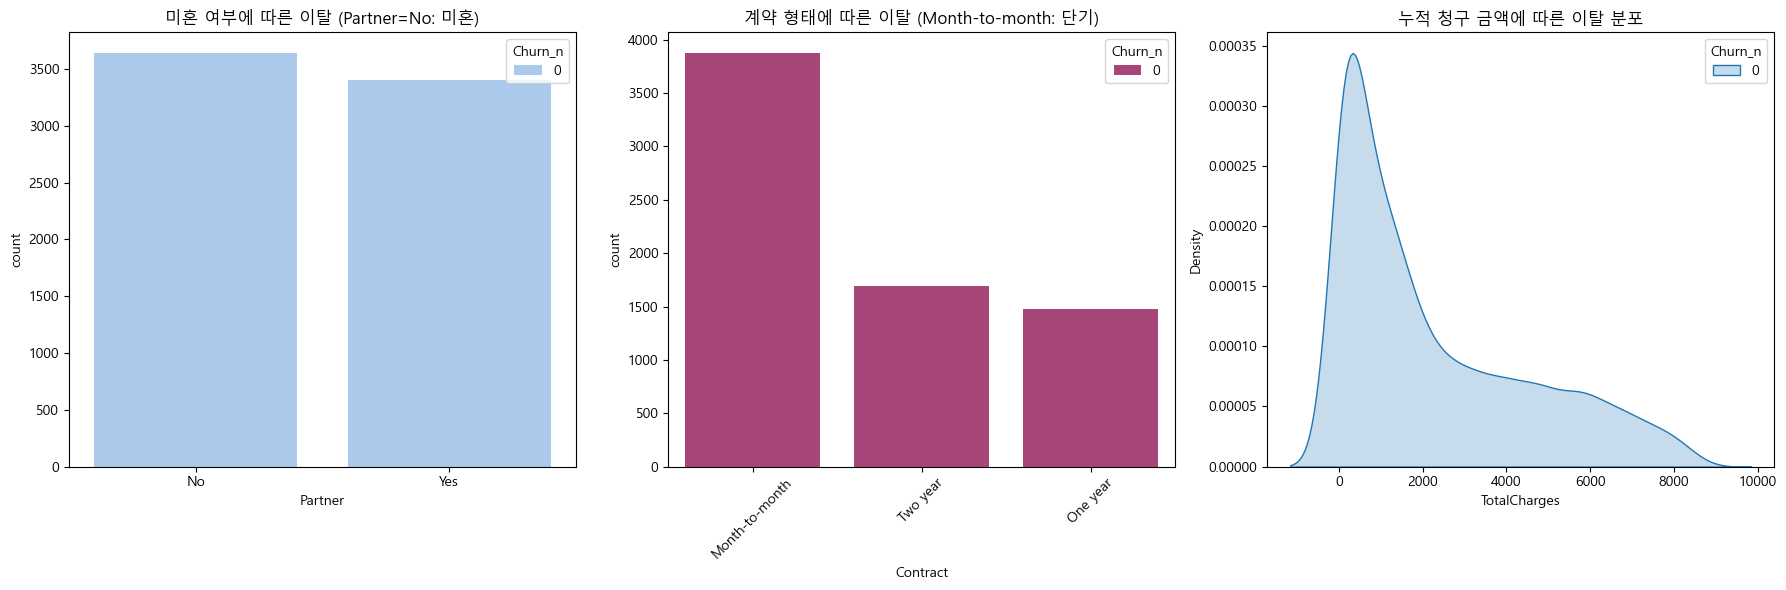

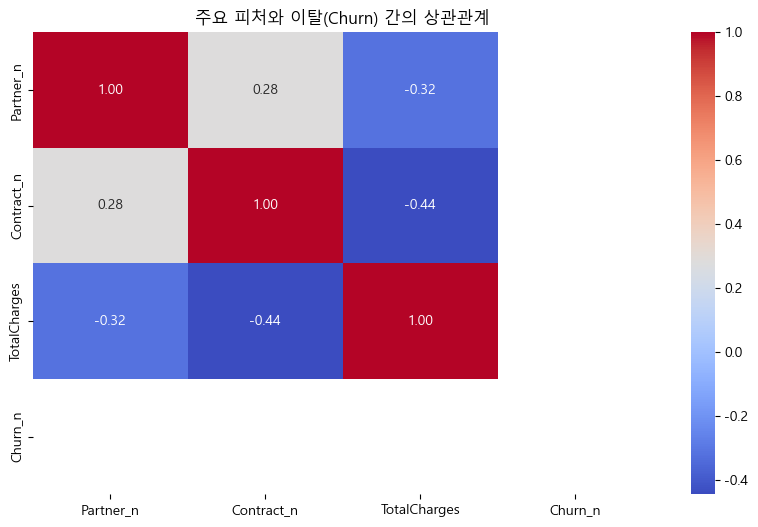

In [10]:

# 1. 데이터 로드 및 전처리 (이전 단계의 전처리가 완료되었다고 가정)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
# 'Yes'는 1로, 'No'는 0으로 변환하여 새로운 컬럼 생성

# 시각화를 위한 한글 설정 (필요 시)
plt.rc('font', family='Malgun Gothic') # Windows 기준
plt.rcParams['axes.unicode_minus'] = False

# 2. 분석을 위한 서브플롯 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# [도표 1] 미혼 여부(Partner)와 이탈 관계
sns.countplot(data=df, x='Partner', hue='Churn_n', ax=axes[0], palette='pastel')
axes[0].set_title('미혼 여부에 따른 이탈 (Partner=No: 미혼)')

# [도표 2] 계약 기간(Contract)과 이탈 관계
sns.countplot(data=df, x='Contract', hue='Churn_n', ax=axes[1], palette='magma')
axes[1].set_title('계약 형태에 따른 이탈 (Month-to-month: 단기)')
axes[1].tick_params(axis='x', rotation=45)

# [도표 3] 누적 청구 금액(TotalCharges) 분포와 이탈
sns.kdeplot(data=df, x='TotalCharges', hue='Churn_n', fill=True, ax=axes[2], common_norm=False)
axes[2].set_title('누적 청구 금액에 따른 이탈 분포')

plt.tight_layout()
plt.show()

# 3. [추가] 상관계수 히트맵 (요청하신 주요 피처 중심)
# 범주형을 숫자로 임시 변환하여 상관관계 확인
temp_df = df.copy()
temp_df['Partner_n'] = (temp_df['Partner'] == 'No').astype(int)
temp_df['Contract_n'] = (temp_df['Contract'] == 'Month-to-month').astype(int)
temp_df['Churn_Value'] = (temp_df['Churn_n'] == 'Yes').astype(int)

plt.figure(figsize=(10, 6))
sns.heatmap(temp_df[['Partner_n', 'Contract_n', 'TotalCharges', 'Churn_n']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('주요 피처와 이탈(Churn) 간의 상관관계')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. 데이터 로드 및 컬럼명 정리 (빈칸 제거)
#df = pd.read_csv('../00_data/Telco_customer_churn - Telco_Churn.csv')

# 2. 필수 전처리 (TotalCharges)
#df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. 파생 피처 생성
df['is_single_short_contract'] = ((df['Partner'] == 'No') &
                                  (df['Contract'] == 'Month-to-month')).astype(int)

charge_threshold = df['TotalCharges'].quantile(0.25)
df['is_low_total_charge'] = (df['TotalCharges'] <= charge_threshold).astype(int)

df['high_risk_segment'] = ((df['is_single_short_contract'] == 1) &
                           (df['is_low_total_charge'] == 1)).astype(int)

# 4. [핵심 수정] 범주형 데이터 자동 인코딩
le = LabelEncoder()

# 숫자가 아닌(object 타입) 모든 컬럼을 찾아서 변환합니다.
# 'CustomerID'나 'Churn'처럼 제외해야 할 컬럼은 미리 처리하거나 리스트에서 뺍니다.
object_cols = df.select_dtypes(include=['object']).columns

for col in object_cols:
    if col in df.columns:
        # 데이터에 'United States' 같은 값이 섞여 있어도 여기서 모두 숫자로 변환됩니다.
        df[col] = le.fit_transform(df[col].astype(str))

# 타겟 변수 설정 (기존에 Churn_n을 만드셨다면 확인 필요)
if 'Churn' in df.columns and 'Churn_n' not in df.columns:
    df['Churn_n'] = df['Churn'] # 이미 위에서 인코딩됨

# 5. 피처 선택 (불필요한 ID 및 타겟 제거)
# 컬럼명에 빈칸을 없앴으므로 'CustomerID'로 접근해야 합니다.
drop_cols = ['CustomerID', 'Churn', 'Churn_n']
features = df.drop([c for c in drop_cols if c in df.columns], axis=1)
target = df['Churn_n']

# 6. 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("에러 없이 전처리가 완료되었습니다!")
print(f"최종 피처 개수: {features.shape[1]}개")

에러 없이 전처리가 완료되었습니다!
최종 피처 개수: 35개


In [12]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'ZipCode', 'LatLong',
       'Latitude', 'Longitude', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'TenureMonths', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'ChurnLabel', 'ChurnValue', 'ChurnScore', 'CLTV', 'ChurnReason',
       'Churn_n', 'is_single_short_contract', 'is_low_total_charge',
       'high_risk_segment'],
      dtype='object')
